# 07 - Turning a risk score into a decision

**Split method:** cutoffs are chosen **only on the pooled walk-forward check-block predictions** (development data, 4 rounds). The test group is used once, later, through the saved scores in `data/staging/final_test_scores.csv`; `test.csv` is never opened here.

## What a cutoff point means

The model gives every transaction a score (how suspicious it looks). The **cutoff** is a line across those scores:
- **at or above the line:** the transaction is **flagged**, an alert for the fraud team (or a blocked payment);
- **below the line:** it is **let through** as genuine, and nobody looks at it.

A higher line means fewer alerts, mostly real fraud, but more fraud slipping through; a lower line catches more fraud but buries the team in false alarms.

## Part 1: The headline-range cutoff

The main metric (AUCPR over recall 0 to 0.2) scores the model's *ranking*, not a line, so it can't pick a cutoff by itself. The cutoff that matches it is the line that captures exactly its range: **the score at which 20% of the fraud has been caught**, working down from the most suspicious transaction. Above that line is the part of the list the headline metric vouches for.

The round predictions are rebuilt with `run_walk_forward` (XGBoost, 29 features), which is reproducible; the pooled headline score is checked against notebook 05's 0.9688.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef

from src.walk_forward import aucpr_low_recall, cutoff_at_recall, feature_columns, run_walk_forward

print(sys.executable)

development = pd.read_csv("../data/processed/development.csv")
recall_limit = 0.2

xgb_rounds, pooled_answers, pooled_scores, xgb_models = run_walk_forward(development, "XGBoost", recall_limit, feature_columns)
print(f"pooled check rows: {len(pooled_answers):,}, fraud: {pooled_answers.sum()}")
print(f"pooled low-recall AUCPR (should match notebook 05's 0.9688): {aucpr_low_recall(pooled_answers, pooled_scores, recall_limit):.4f}")

C:\Users\RevathyHarichandran\Desktop\portfolio projects\Fraud_detection\.venv\Scripts\python.exe


pooled check rows: 176,175, fraud: 250
pooled low-recall AUCPR (should match notebook 05's 0.9688): 0.9688


### Pooled or last round only?

- **All four rounds pooled:** 250 fraud, so 20% recall rests on about 50 fraud cases (more stable), but it mixes four round models whose scores are pitched differently, so one shared cutoff can mean slightly different things for each.
- **Round 4 only:** its model is closest to the final one (it learned from blocks 1 to 4), but its check block has 50 fraud, so 20% recall rests on about 10 (one fraud more or less moves the line a lot).

So the cutoff is found in **each round separately**, **pooled**, and for **round 4**. `cutoff_at_recall` (in `src/walk_forward.py`, checked on a small known example first) sorts transactions from most to least suspicious, counts frauds found so far (the same idea as notebook 06's depth table), takes the score where 20% is reached, then reports what flagging everything at or above it would do: alerts, fraud caught, **precision**, **recall**, and the **alert rate** (share of all transactions flagged).

**MCC** (secondary, explained in notebook 06) is calculated at each cutoff on this check data with scikit-learn's `matthews_corrcoef`; `scores >= cutoff` turns the scores into yes/no flags. The round slicing by position is the same as notebook 05, Part 5.

**Rule fixed before seeing the numbers:** if the four per-round cutoffs are similar, use the pooled cutoff for stability; if they differ substantially, show both with the trade-off and let the user choose.

In [2]:
target_recall = 0.2

check_sizes = []
for round_number in range(1, 5):
    check_rows = development[(development["block"] == round_number + 1) & (~development["in_gap"])]
    check_sizes.append(len(check_rows))

cutoff_rows = []
start = 0
for round_number in range(1, 5):
    end = start + check_sizes[round_number - 1]
    round_answers = pooled_answers[start:end]
    round_scores = pooled_scores[start:end]
    result = cutoff_at_recall(round_answers, round_scores, target_recall)
    result["where"] = "round " + str(round_number)
    result["mcc"] = matthews_corrcoef(round_answers, round_scores >= result["cutoff"])
    cutoff_rows.append(result)
    start = end

pooled_result = cutoff_at_recall(pooled_answers, pooled_scores, target_recall)
pooled_result["where"] = "pooled"
pooled_result["mcc"] = matthews_corrcoef(pooled_answers, pooled_scores >= pooled_result["cutoff"])
cutoff_rows.append(pooled_result)

cutoff_table = pd.DataFrame(cutoff_rows)
cutoff_table = cutoff_table[["where", "cutoff", "alerts", "fraud_caught", "total_fraud", "precision", "recall", "alert_rate", "mcc"]]
print(cutoff_table.round(6).to_string(index=False))

  where   cutoff  alerts  fraud_caught  total_fraud  precision   recall  alert_rate      mcc
round 1 0.999976      14            14           66   1.000000 0.212121    0.000318 0.460294
round 2 0.999997      12            10           46   0.833333 0.217391    0.000272 0.425375
round 3 0.999997      18            18           88   1.000000 0.204545    0.000408 0.451908
round 4 0.999993      10            10           50   1.000000 0.200000    0.000228 0.447010
 pooled 0.999994      52            50          250   0.961538 0.200000    0.000295 0.438258


### How uncertain is each cutoff?

A 95% bootstrap interval for the **cutoff score itself** (1,000 resamples, seed 42): resample the check rows with replacement, find the 20%-recall cutoff again, and see how far it moves. It shows whether about 10 fraud cases (round 4) or about 50 (pooled) are enough to place the line reliably.

In [3]:
round_4_start = check_sizes[0] + check_sizes[1] + check_sizes[2]
candidates = {
    "pooled": [pooled_answers, pooled_scores],
    "round 4": [pooled_answers[round_4_start:], pooled_scores[round_4_start:]],
}

for name, (answers, scores) in candidates.items():
    rng = np.random.default_rng(42)
    resampled_cutoffs = []
    for resample_number in range(1000):
        positions = rng.integers(0, len(answers), size=len(answers))
        resampled_cutoffs.append(cutoff_at_recall(answers[positions], scores[positions], target_recall)["cutoff"])
    print(f"{name:8s} cutoff 95% CI {np.percentile(resampled_cutoffs, 2.5):.6f} to {np.percentile(resampled_cutoffs, 97.5):.6f}")

pooled   cutoff 95% CI 0.999986 to 0.999996


round 4  cutoff 95% CI 0.999985 to 0.999997


In the cell above, `candidates.items()` goes through a dictionary giving each name together with its value, and `(answers, scores)` unpacks that value's two parts (loop unpacking, notebook 05).

**What this shows** (results only; the choice follows):
- **The 20%-recall cutoff is extremely high in every case:** 0.999976 to 0.999997. Class weighting pushes fraud-like scores right up against 1, so the line sits in a very thin band near the top.
- **What it does:** it flags only about **0.03% of transactions** (alert rate 0.023% to 0.041% per round; 52 alerts across all 176,175 pooled check transactions), and those alerts are **83% to 100% real fraud** (pooled 96%, 50 of 52).
- **MCC at this cutoff is only about 0.44 to 0.46**, despite near-perfect precision, because the line deliberately catches only 20% of the fraud and lets 80% through. That is exactly why MCC is secondary: it judges the whole yes/no picture, while this cutoff is built for the limited-alerts reality.
- **Are the per-round cutoffs similar?** In raw score they all look nearly identical (0.99998 to 0.99999), but that is misleading: scores this close to 1 are squashed together, and the same "top fifth of the fraud" corresponds to flagging between 0.023% and 0.041% of transactions depending on the round, nearly a factor of two. In alert-rate terms they are similar in size but not the same.
- **Uncertainty:** the cutoff's 95% interval is 0.999986 to 0.999996 pooled and 0.999985 to 0.999997 for round 4 alone, similar widths; round 4's 10 fraud cases did not make its line noticeably less stable here.

## Part 2: Where does the model stay reliable? Depth table and curve on the check blocks

The test group's precision-recall curve (notebook 06) can't be used to choose a cutoff: that would mean choosing the line where we already know the test results look good, then "testing" it on the same data. The **same idea is applied here to the walk-forward check blocks**, which exist so choices can be made on them.

**The depth table** (pooled, 250 fraud): for recall 10%, 20%, ... 100%, `cutoff_at_recall` gives the cutoff score, the alerts needed, precision, and the alert rate.

**The chart:** the pooled precision-recall curve as a bold step line, plus each round's own curve as a thin line. Each round's curve comes from one model, so it has no pitch problem; if the rounds agree with the pooled curve, the pooled picture can be trusted. Saved as `outputs/figures/09_precision_recall_curve_check_blocks.png`.

In [4]:
depth_rows = []
for step in range(1, 11):
    recall_target = step / 10
    result = cutoff_at_recall(pooled_answers, pooled_scores, recall_target)
    depth_rows.append({
        "recall target": f"{recall_target:.0%}",
        "fraud caught": result["fraud_caught"],
        "alerts": result["alerts"],
        "precision": result["precision"],
        "alert rate": result["alert_rate"],
        "cutoff score": result["cutoff"],
        "mcc": matthews_corrcoef(pooled_answers, pooled_scores >= result["cutoff"]),
    })

check_depth = pd.DataFrame(depth_rows)
check_depth.to_csv("../outputs/tables/check_blocks_alert_depth.csv", index=False)
print(f"pooled check blocks: {len(pooled_answers):,} transactions, {pooled_answers.sum()} fraud")
print(check_depth.to_string(index=False, formatters={"precision": "{:.3f}".format,
                                                      "alert rate": "{:.5%}".format,
                                                      "cutoff score": "{:.6f}".format,
                                                      "mcc": "{:.3f}".format}))

pooled check blocks: 176,175 transactions, 250 fraud
recall target  fraud caught  alerts precision alert rate cutoff score   mcc
          10%            25      26     0.962   0.01476%     0.999998 0.310
          20%            50      52     0.962   0.02952%     0.999994 0.438
          30%            75      81     0.926   0.04598%     0.999976 0.527
          40%           100     106     0.943   0.06017%     0.999945 0.614
          50%           125     131     0.954   0.07436%     0.999864 0.690
          60%           150     159     0.943   0.09025%     0.999155 0.752
          70%           175     199     0.879   0.11296%     0.966289 0.784
          80%           200     550     0.364   0.31219%     0.006167 0.538
          90%           225   22002     0.010  12.48872%     0.000015 0.088
         100%           250  148647     0.002  84.37463%     0.000000 0.016


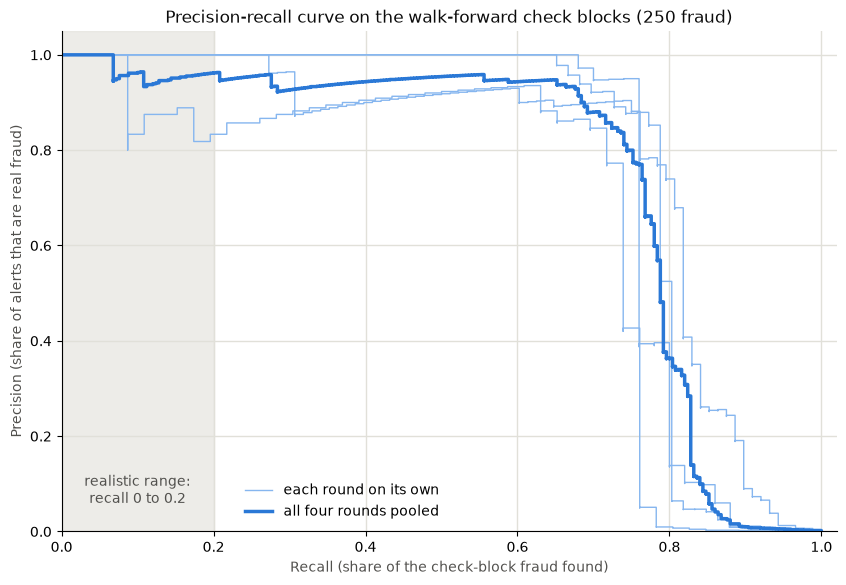

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.axvspan(0, 0.2, color="#e1e0d9", alpha=0.6)
ax.text(0.1, 0.06, "realistic range:\nrecall 0 to 0.2", ha="center", color="#52514e")

# Each round's own curve (one model each, so no score-pitch problem), thin.
start = 0
for round_number in range(1, 5):
    end = start + check_sizes[round_number - 1]
    round_precision, round_recall, round_thresholds = precision_recall_curve(pooled_answers[start:end], pooled_scores[start:end])
    if round_number == 1:
        ax.plot(round_recall, round_precision, drawstyle="steps-post", color="#86b6ef", linewidth=1, label="each round on its own")
    else:
        ax.plot(round_recall, round_precision, drawstyle="steps-post", color="#86b6ef", linewidth=1)
    start = end

# The pooled curve, bold.
pooled_precision, pooled_recall, pooled_thresholds = precision_recall_curve(pooled_answers, pooled_scores)
ax.plot(pooled_recall, pooled_precision, drawstyle="steps-post", color="#2a78d6", linewidth=2.5, label="all four rounds pooled")

ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall (share of the check-block fraud found)", color="#52514e")
ax.set_ylabel("Precision (share of alerts that are real fraud)", color="#52514e")
ax.set_title("Precision-recall curve on the walk-forward check blocks (250 fraud)", color="#0b0b0b")
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0.22, 0.0))
ax.grid(color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/09_precision_recall_curve_check_blocks.png", dpi=150, bbox_inches="tight")
plt.show()

In the depth-table cell, `formatters` tells `to_string` how to print chosen columns: `"{:.3f}".format` means "3 decimal places", `"{:.5%}".format` "as a percentage with 5 decimals".

**What this shows:**
- **A long, stable plateau:** from the first alert to about 60% of the fraud, alerts stay 93% to 96% real fraud.
- **A cliff between 70% and 80% recall:** at 70%, precision is 88% (199 alerts); reaching 80% needs 550 alerts and precision falls to 36%; beyond that it is close to guessing.
- **The four rounds agree:** each round's own curve (one model, no pitch problem) shows the same plateau then cliff, with the cliff falling somewhere between about 73% and 82% recall depending on the round.
- **MCC rises along the plateau and peaks around 70% recall (0.78)**, just before the cliff.

## Decision: the main cutoff

**Chosen (user's decision): option B, the end of the stable plateau, catching 60% of the check-block fraud.**
- **Expressed as an alert rate: flag the top 0.090% of transactions** (pooled check blocks: 159 alerts, 150 fraud, precision 94%, MCC 0.75). Carried to the test group as an alert rate, applied to the saved test scores by their order only (never the labels), because raw scores are pitched differently between the round models and the final model.
- **Raw cutoff score at this point: 0.999155**, recorded for transparency only.
- **Why B:** three times the fraud of the headline-range line (60% against 20%) with alerts just as clean (94% against 96%), and a safety margin before the cliff, whose position shifts between rounds. The 70% line (MCC 0.78) was allowed but sits at the cliff's edge; the 20% headline-range line (MCC 0.44) catches much less.
- Roughly 120 alerts a day at the development data's volume (about 135,000 transactions a day).

## Part 3: The cost-based cutoff

**The user's cost assumptions** (business assumptions, in the same unnamed units as Amount; see DECISIONS.md): a missed fraud costs its own **Amount + 20**; a false alarm **8**; a caught fraud **3** (review time); a genuine transaction let through **0**.

Slide the line down the list from most to least suspicious and add up the total cost at every position:

total cost = 3 × frauds caught + 8 × false alarms + Σ (Amount + 20) over every fraud still missed

Early on each step catches fraud worth far more than 8, so cost falls; past the plateau each step mostly adds false alarms, so it climbs. **The cost-based cutoff is where total cost is lowest.** Unlike the first cutoff, it uses each fraud's real Amount.

`cost_by_alerts` (in `src/walk_forward.py`, checked first on a 5-transaction example worked out by hand) calculates the cost at every position in one pass using running totals (`cumsum`), and returns two lists: number of alerts (0, 1, 2, ...) and total cost. `np.argmin` gives the position of the smallest value.

**Lining up Amount:** the pooled scores don't carry Amount, so the pooled Amount list is rebuilt in exactly the same order (rounds 1 to 4, gap rows excluded), and checked by confirming its fraud labels match the pooled answers position for position.

In [6]:
from src.walk_forward import cost_by_alerts

cost_caught = 3
cost_false_alarm = 8
missed_fee = 20

# Rebuild the pooled Amount list in the same order as the pooled scores.
amount_parts = []
class_parts = []
for round_number in range(1, 5):
    check_rows = development[(development["block"] == round_number + 1) & (~development["in_gap"])]
    amount_parts.append(check_rows["Amount"].to_numpy())
    class_parts.append(check_rows["Class"].to_numpy())
pooled_amounts = np.concatenate(amount_parts)
print("Amount lined up with the pooled answers:", np.array_equal(np.concatenate(class_parts), pooled_answers))

alerts, total_cost = cost_by_alerts(pooled_answers, pooled_scores, pooled_amounts, cost_caught, cost_false_alarm, missed_fee)
best_alerts = alerts[np.argmin(total_cost)]


def describe_top(answers, scores, number_of_alerts):
    # What flagging the number_of_alerts most suspicious transactions does
    # (number_of_alerts must be at least 1).
    order = np.argsort(-scores, kind="stable")
    flagged = np.zeros(len(scores), dtype=bool)
    flagged[order[:number_of_alerts]] = True
    fraud_caught = answers[flagged].sum()
    return {
        "alerts": number_of_alerts,
        "alert rate": number_of_alerts / len(scores),
        "fraud caught": fraud_caught,
        "precision": fraud_caught / number_of_alerts,
        "recall": fraud_caught / answers.sum(),
        "mcc": matthews_corrcoef(answers, flagged),
        "raw cutoff": scores[order[number_of_alerts - 1]],
    }


plateau_alerts = cutoff_at_recall(pooled_answers, pooled_scores, 0.6)["alerts"]

comparison_rows = []
comparison_rows.append({"line": "flag nothing", "alerts": 0, "fraud caught": 0, "total cost": total_cost[0]})

plateau_row = describe_top(pooled_answers, pooled_scores, plateau_alerts)
plateau_row["line"] = "plateau line (first cutoff)"
plateau_row["total cost"] = total_cost[plateau_alerts]
comparison_rows.append(plateau_row)

cost_row = describe_top(pooled_answers, pooled_scores, best_alerts)
cost_row["line"] = "cost-based line"
cost_row["total cost"] = total_cost[best_alerts]
comparison_rows.append(cost_row)

cost_comparison = pd.DataFrame(comparison_rows)
cost_comparison = cost_comparison[["line", "alerts", "alert rate", "fraud caught", "precision", "recall", "mcc", "raw cutoff", "total cost"]]
cost_comparison.to_csv("../outputs/tables/cost_based_cutoff_check_blocks.csv", index=False)
print()
print(cost_comparison.round(6).to_string(index=False))

Amount lined up with the pooled answers: True

                       line  alerts  alert rate  fraud caught  precision  recall      mcc  raw cutoff  total cost
               flag nothing       0         NaN             0        NaN     NaN      NaN         NaN    41061.23
plateau line (first cutoff)     159    0.000903           150   0.943396   0.600 0.752096    0.999155    16670.38
            cost-based line     346    0.001964           197   0.569364   0.788 0.669283    0.038210    12645.47


In the cell above: `np.zeros(n, dtype=bool)` makes a list of n `False` values (`dtype=bool` means true/false values); `order[:number_of_alerts]` is the positions of the top transactions (slicing, notebook 05); setting those to `True` marks them as flagged.

### Does the fraud rate move the cost-based line? Each round on its own, and a bootstrap

The cost-based line balances "how likely is a transaction near the line to be fraud?" against the costs, so a period with less fraud should favour flagging fewer, and one with more fraud flagging more. The check blocks' fraud rates range from about 0.10% to 0.20%, so finding the cost-based line **in each round separately**, next to that round's fraud rate, shows whether the effect is real here (using check data only).

Then a **bootstrap interval** for the pooled cost-based alert rate (1,000 resamples, seed 42; Amount travels with each resampled row) shows how precisely it is pinned down.

In [7]:
round_rows = []
start = 0
for round_number in range(1, 5):
    end = start + check_sizes[round_number - 1]
    round_answers = pooled_answers[start:end]
    round_scores = pooled_scores[start:end]
    round_amounts = pooled_amounts[start:end]
    round_alerts, round_cost = cost_by_alerts(round_answers, round_scores, round_amounts, cost_caught, cost_false_alarm, missed_fee)
    round_best = round_alerts[np.argmin(round_cost)]
    round_row = describe_top(round_answers, round_scores, round_best)
    round_row["round"] = round_number
    round_row["fraud rate"] = round_answers.mean()
    round_rows.append(round_row)
    start = end

round_cost_table = pd.DataFrame(round_rows)
round_cost_table = round_cost_table[["round", "fraud rate", "alerts", "alert rate", "fraud caught", "precision", "recall", "mcc"]]
print("Cost-based line found in each round on its own:")
print(round_cost_table.to_string(index=False, formatters={"fraud rate": "{:.4%}".format, "alert rate": "{:.4%}".format,
                                                          "precision": "{:.3f}".format, "recall": "{:.3f}".format, "mcc": "{:.3f}".format}))
print()

rng = np.random.default_rng(42)
resampled_rates = []
for resample_number in range(1000):
    positions = rng.integers(0, len(pooled_answers), size=len(pooled_answers))
    resampled_alerts, resampled_cost = cost_by_alerts(pooled_answers[positions], pooled_scores[positions], pooled_amounts[positions],
                                                      cost_caught, cost_false_alarm, missed_fee)
    resampled_rates.append(resampled_alerts[np.argmin(resampled_cost)] / len(positions))

print(f"pooled cost-based alert rate: {best_alerts / len(pooled_answers):.4%}"
      f"  95% CI {np.percentile(resampled_rates, 2.5):.4%} to {np.percentile(resampled_rates, 97.5):.4%}")

Cost-based line found in each round on its own:
 round fraud rate  alerts alert rate  fraud caught precision recall   mcc
     1    0.1499%      61    0.1386%            52     0.852  0.788 0.819
     2    0.1043%      39    0.0884%            33     0.846  0.717 0.779
     3    0.1995%     211    0.4783%            74     0.351  0.841 0.542
     4    0.1138%      40    0.0910%            38     0.950  0.760 0.850



pooled cost-based alert rate: 0.1964%  95% CI 0.1169% to 0.2486%


### The cost curve

Total cost against the number of alerts, with both cutoffs marked. The number of alerts runs from 1 to over 176,000, so the bottom axis uses a **log scale** (notebook 02): each step to the right multiplies the alerts by 10, which keeps the interesting part (tens to hundreds of alerts) readable. Saved as `outputs/figures/10_cost_curve_check_blocks.png`.

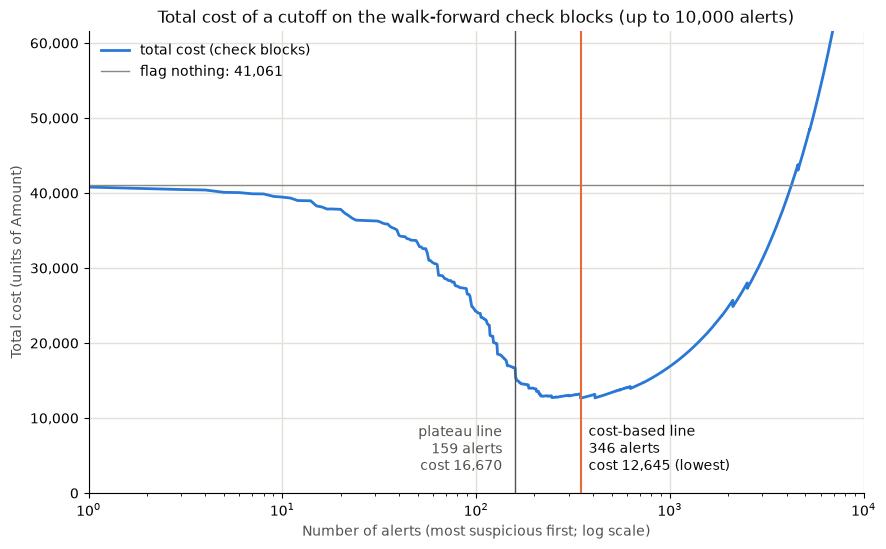

In [8]:
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(10, 6))

# Position 0 (flag nothing) can't be shown on a log scale, so the curve starts at 1 alert.
ax.plot(alerts[1:], total_cost[1:], color="#2a78d6", linewidth=2, label="total cost (check blocks)")
ax.axhline(total_cost[0], color="#898781", linewidth=1, label=f"flag nothing: {total_cost[0]:,.0f}")

# Zoom in: beyond about 10,000 alerts the cost explodes (over 1.4 million at
# 176,000 alerts) and would squash the interesting part flat.
top_of_chart = total_cost[0] * 1.5
ax.set_xlim(1, 10000)
ax.set_ylim(0, top_of_chart)

# Labels sit below the curve's lowest point, in empty space.
ax.axvline(plateau_alerts, color="#52514e", linewidth=1)
ax.text(plateau_alerts * 0.9, top_of_chart * 0.05, f"plateau line \n{plateau_alerts} alerts \ncost {total_cost[plateau_alerts]:,.0f} ",
        color="#52514e", ha="right")
ax.axvline(best_alerts, color="#eb6834", linewidth=1.5)
ax.text(best_alerts * 1.1, top_of_chart * 0.05, f"cost-based line\n{best_alerts} alerts\ncost {total_cost[best_alerts]:,.0f} (lowest)",
        color="#0b0b0b", ha="left")

ax.set_xscale("log")
ax.set_xlabel("Number of alerts (most suspicious first; log scale)", color="#52514e")
ax.set_ylabel("Total cost (units of Amount)", color="#52514e")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Total cost of a cutoff on the walk-forward check blocks (up to 10,000 alerts)", color="#0b0b0b")
ax.legend(frameon=False, loc="upper left")
ax.grid(color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/10_cost_curve_check_blocks.png", dpi=150, bbox_inches="tight")
plt.show()

**What this shows** (results only; the decision follows):
- **The cost-based line flags 346 transactions (top 0.196%)**: it catches 197 of 250 frauds (79%), with 57% of alerts real, MCC 0.67, total cost 12,645. The plateau line (159 alerts, 60% caught, 94% real) costs 16,670; flagging nothing costs 41,061.
- **Why it goes further than the plateau line, past the cliff:** a missed fraud costs its Amount + 20 (about 30 for a typical one, far more for large ones), while a false alarm costs 8, so catching one more fraud is worth it even at the price of a few false alarms. The costs say it pays to accept a busier, noisier queue in exchange for catching more fraud.
- **The valley is wide and flat:** cost stays near its lowest from about 200 to 400 alerts, so the exact best point is not sharply defined; the bootstrap interval for the cost-based alert rate is 0.117% to 0.249%.
- **The fraud rate clearly moves the cost-based line:** rounds 2 and 4 (fraud rate about 0.10% to 0.11%) favour flagging about 0.09%; round 1 (0.15%) about 0.14%; round 3 (0.20%, containing the second night) about 0.48%, five times as many. The pooled 0.196% is pulled up by round 3.

## Decision: the cost-based cutoff, and the fraud-rate question

**Chosen (user's decision, option A): keep the pooled cost-based line, flag the top 0.196% of transactions**, exactly as the rule was set (minimise cost on the check blocks). It is carried to the test group as an alert rate, like the plateau line. Raw cutoff at this point: 0.038210 (transparency only).

**The fraud-rate sensitivity is reported, not adjusted:** the best cost-based line rises with the fraud rate (0.088% to 0.091% of transactions in the low-fraud rounds, 0.478% in the high-fraud round 3). The pooled line is tuned to an average fraud rate of about 0.142%, pulled up by round 3, so it may flag more than ideal for a lower-fraud period such as the test group (0.134%). Adjusting with the test group's actual fraud rate is ruled out (that would use test information to set the line). A "typical period" median of the rounds was considered (option B) and not chosen, as choosing it after seeing round 3's effect would be a post-hoc adjustment.

**Real-world recommendation (option C):** in deployment, monitor the fraud rate and the alert queue every week and re-tune the line regularly, because the cost-optimal line moves with how much fraud is happening.

## Part 4: Applying both cutoffs to the test group, once

Both cutoffs were fixed on the check blocks. This is their one honest check, on data they never influenced.

1. **Read the saved test scores** (`data/staging/final_test_scores.csv`, from notebook 06). No re-scoring.
2. **Flag by rank, using the scores' order only** (never the labels): alerts = alert rate × 55,372, rounded to the nearest whole alert (`round`): plateau 0.0903% → about 50, cost-based 0.1964% → about 109.
3. **Only then** compare the flags with the real answers: frauds caught, missed, false alarms, correctly let through; precision, recall, **MCC**, and **total cost** under the user's cost model.
4. **Amount for the cost:** the saved scores don't hold Amount, so it is looked up by `row_id` from `test.csv` (only the `row_id` and `Amount` columns, via `usecols`), purely to report cost. No scoring, no choice. `merge` joins two tables on a shared column, like matching rows by ID.
5. **95% bootstrap intervals** (1,000 resamples, seed 42) for precision, recall, MCC and cost; each resample keeps every transaction's flag as it was decided.
6. **For transparency only:** what each raw score cutoff from the check blocks would have flagged on the test scores (no decision is taken from this).

In [9]:
test_scores_table = pd.read_csv("../data/staging/final_test_scores.csv")
test_amounts_table = pd.read_csv("../data/processed/test.csv", usecols=["row_id", "Amount"])
test_table = test_scores_table.merge(test_amounts_table, on="row_id")
print("test rows:", len(test_table), "| fraud:", test_table["Class"].sum(),
      "| every saved score found its Amount:", len(test_table) == len(test_scores_table))

test_answers = test_table["Class"].to_numpy()
test_scores = test_table["score"].to_numpy()
test_amounts = test_table["Amount"].to_numpy()
test_order = np.argsort(-test_scores, kind="stable")


def outcome_summary(answers, flags, amounts):
    # Counts the four outcomes for a set of yes/no flags, and the total cost
    # under the user's cost model.
    caught = (flags & (answers == 1)).sum()
    false_alarms = (flags & (answers == 0)).sum()
    missed = ((~flags) & (answers == 1)).sum()
    let_through = ((~flags) & (answers == 0)).sum()
    missed_cost = ((amounts + missed_fee) * ((~flags) & (answers == 1))).sum()
    return {
        "alerts": flags.sum(),
        "caught": caught,
        "missed": missed,
        "false alarms": false_alarms,
        "correctly let through": let_through,
        "precision": caught / flags.sum(),
        "recall": caught / answers.sum(),
        "mcc": matthews_corrcoef(answers, flags),
        "total cost": cost_caught * caught + cost_false_alarm * false_alarms + missed_cost,
    }


plateau_rate = plateau_alerts / len(pooled_answers)
cost_rate = best_alerts / len(pooled_answers)

final_rows = []
final_flags = {}
for name, rate in [["plateau line (top 0.090%)", plateau_rate], ["cost-based line (top 0.196%)", cost_rate]]:
    number_of_alerts = round(rate * len(test_scores))
    flags = np.zeros(len(test_scores), dtype=bool)
    flags[test_order[:number_of_alerts]] = True
    final_flags[name] = flags
    row = outcome_summary(test_answers, flags, test_amounts)
    row["line"] = name
    final_rows.append(row)

no_flags = np.zeros(len(test_scores), dtype=bool)
nothing_row = {"line": "flag nothing", "alerts": 0, "caught": 0, "missed": test_answers.sum(), "false alarms": 0,
               "correctly let through": (test_answers == 0).sum(),
               "total cost": ((test_amounts + missed_fee) * test_answers).sum()}
final_rows.insert(0, nothing_row)

final_table = pd.DataFrame(final_rows)
final_table = final_table[["line", "alerts", "caught", "missed", "false alarms", "correctly let through",
                           "precision", "recall", "mcc", "total cost"]]
final_table.to_csv("../outputs/tables/test_final_cutoffs.csv", index=False)
print()
print(final_table.round(4).to_string(index=False))

test rows: 55372 | fraud: 74 | every saved score found its Amount: True

                        line  alerts  caught  missed  false alarms  correctly let through  precision  recall    mcc  total cost
                flag nothing       0       0      74             0                  55298        NaN     NaN    NaN     9207.67
   plateau line (top 0.090%)      50      49      25             1                  55297     0.9800  0.6622 0.8054     4579.06
cost-based line (top 0.196%)     109      59      15            50                  55248     0.5413  0.7973 0.6564     2641.49


In [10]:
# 95% bootstrap intervals: resample test rows, keeping each row's flag as decided.
interval_rows = []
for name in final_flags:
    flags = final_flags[name]
    rng = np.random.default_rng(42)
    resampled = {"precision": [], "recall": [], "mcc": [], "total cost": []}
    for resample_number in range(1000):
        positions = rng.integers(0, len(test_answers), size=len(test_answers))
        summary = outcome_summary(test_answers[positions], flags[positions], test_amounts[positions])
        for measure in resampled:
            resampled[measure].append(summary[measure])
    for measure in resampled:
        interval_rows.append({"line": name, "measure": measure,
                              "ci_lower": np.percentile(resampled[measure], 2.5),
                              "ci_upper": np.percentile(resampled[measure], 97.5)})

interval_table = pd.DataFrame(interval_rows)
interval_table.to_csv("../outputs/tables/test_final_cutoffs_intervals.csv", index=False)
print("95% bootstrap intervals on the test group:")
print(interval_table.round(4).to_string(index=False))
print()

# Transparency only: what the raw score cutoffs from the check blocks would have flagged.
raw_plateau = describe_top(pooled_answers, pooled_scores, plateau_alerts)["raw cutoff"]
raw_cost = describe_top(pooled_answers, pooled_scores, best_alerts)["raw cutoff"]
for name, raw_cutoff in [["plateau raw cutoff", raw_plateau], ["cost-based raw cutoff", raw_cost]]:
    raw_flags = test_scores >= raw_cutoff
    raw_summary = outcome_summary(test_answers, raw_flags, test_amounts)
    print(f"{name} {raw_cutoff:.6f}: would flag {raw_summary['alerts']} test transactions "
          f"({raw_summary['caught']} fraud caught, precision {raw_summary['precision']:.3f})")

95% bootstrap intervals on the test group:
                        line    measure  ci_lower  ci_upper
   plateau line (top 0.090%)  precision    0.9302    1.0000
   plateau line (top 0.090%)     recall    0.5556    0.7628
   plateau line (top 0.090%)        mcc    0.7324    0.8699
   plateau line (top 0.090%) total cost 1743.0910 8315.5830
cost-based line (top 0.196%)  precision    0.4453    0.6291
cost-based line (top 0.196%)     recall    0.7073    0.8810
cost-based line (top 0.196%)        mcc    0.5771    0.7270
cost-based line (top 0.196%) total cost  972.8978 5433.2525

plateau raw cutoff 0.999155: would flag 47 test transactions (46 fraud caught, precision 0.979)
cost-based raw cutoff 0.038210: would flag 85 test transactions (57 fraud caught, precision 0.671)


In the cell above, `(flags & (answers == 1))` marks rows that are both flagged *and* fraud (`&` = "and", `~` = "not", notebook 01); `.sum()` counts them.

**What this shows: the final, honest result of both cutoffs on the test group** (55,372 transactions, 74 fraud; saved scores unchanged, fingerprint checked):

| | Plateau line (top 0.090%) | Cost-based line (top 0.196%) | Flag nothing |
|---|---|---|---|
| Alerts | 50 | 109 | 0 |
| Fraud caught / missed | 49 / 25 | 59 / 15 | 0 / 74 |
| False alarms | 1 | 50 | 0 |
| Precision (95% CI) | 0.98 (0.93 to 1.00) | 0.54 (0.45 to 0.63) | — |
| Recall (95% CI) | 0.66 (0.56 to 0.76) | 0.80 (0.71 to 0.88) | 0 |
| MCC (95% CI) | 0.81 (0.73 to 0.87) | 0.66 (0.58 to 0.73) | — |
| Total cost (95% CI) | 4,579 (1,743 to 8,316) | 2,641 (973 to 5,433) | 9,208 |

- **Both cutoffs held up on data they never influenced.** On the check blocks the plateau line caught 60% of fraud at 94% precision; on the test group 66% at 98%. The cost-based line caught 79% at 57% precision; on the test group 80% at 54%.
- **The plateau line:** 50 alerts, 49 of them real fraud, one false alarm. It halves the cost of doing nothing.
- **The cost-based line:** catches 10 more frauds at the price of 49 more false alarms, and has the lowest total cost (2,641, about 71% below doing nothing), as designed.
- **The cost intervals are wide and overlap:** total cost is dominated by the Amounts of a few missed frauds, so it swings a lot between resamples. These two cutoffs were not compared with a paired test here; the decisions were already fixed on the check blocks.
- **Transparency, raw score cutoffs:** the plateau raw cutoff (0.999155) would have flagged 47 test transactions (46 fraud), close to the rank rule's 50. The cost-based raw cutoff (0.038210) would have flagged only 85 (57 fraud) rather than 109, showing the final model's scores are pitched differently from the round models' lower down the list, which is why the cutoffs were carried as alert rates.
- **MCC, reported here as the secondary number deferred from Phase 6:** 0.81 for the plateau line and 0.66 for the cost-based line.

## Part 5: The final result as a confusion matrix

A **confusion matrix** is a 2×2 table that puts every test transaction in one of four boxes: rows are what the transaction **really was** (genuine or fraud), columns are what **the model decided** (let through or flagged).

| | let through | flagged |
|---|---|---|
| **really genuine** | correctly let through | **false alarm** |
| **really fraud** | **missed fraud** | fraud caught |

Drawn as a **heatmap**: each box is coloured, so the picture can be read at a glance. Both cutoffs are drawn side by side from the flags already made in Part 4 (`final_flags`); nothing is re-scored or re-decided. Saved as `outputs/figures/11_confusion_matrix_test.png`.

- **Counting:** scikit-learn's `confusion_matrix(answers, flags, labels=[0, 1])`. `labels=[0, 1]` fixes the order of rows and columns as genuine (0) then fraud (1), so the table is laid out as above; the counts are checked against Part 4's hand counts rather than trusted. (Alternative: count by hand again, already done in Part 4, which is why it works as a cross-check.)
- **Colour = share of the box's own row**, not the raw count. Otherwise the 55,000-transaction box would be dark and the other three would all look equally empty. So the missed-fraud box is coloured by "share of all fraud missed" (for example 25 of 74). The real count is written in every box in large text. (Alternative not used: a log colour scale, harder to explain to someone new.)
- **Drawing:** matplotlib's `imshow` draws a grid of coloured squares from a table of numbers (`cmap="Blues"`: white for 0% up to dark blue for 100%; `vmin=0, vmax=1` fixes that range so both pictures use the same colours), and `ax.text` writes the numbers on top. (Alternative not used: scikit-learn's `ConfusionMatrixDisplay`, which colours by raw count and allows less control over the plain-English labels.)

plateau line (top 0.090%) | counts: [[55297, 1], [25, 49]] | matches Part 4: True
cost-based line (top 0.196%) | counts: [[55248, 50], [15, 59]] | matches Part 4: True


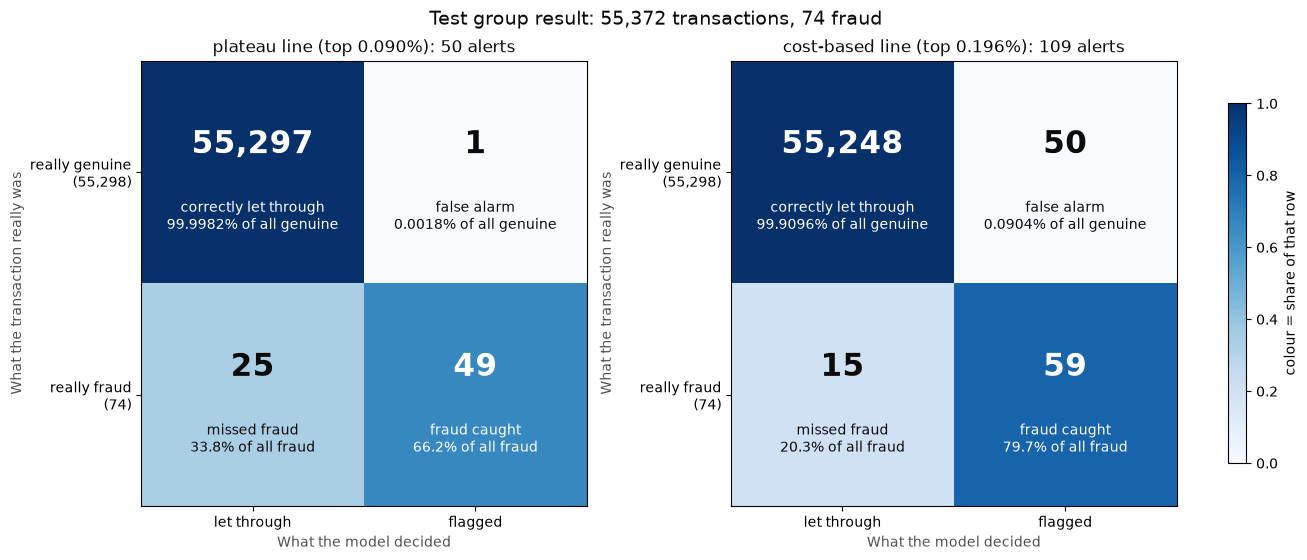

In [11]:
from sklearn.metrics import confusion_matrix

box_names = [["correctly let through", "false alarm"],
             ["missed fraud", "fraud caught"]]
row_names = ["genuine", "fraud"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
panel = 0
for name in final_flags:
    flags = final_flags[name]
    counts = confusion_matrix(test_answers, flags, labels=[0, 1])

    # Cross-check against Part 4's hand counts, box by box.
    summary = outcome_summary(test_answers, flags, test_amounts)
    expected = [[summary["correctly let through"], summary["false alarms"]],
                [summary["missed"], summary["caught"]]]
    print(name, "| counts:", counts.tolist(), "| matches Part 4:", counts.tolist() == expected)

    # Each box's share of its own row (genuine row adds up to 100%, fraud row too).
    row_totals = counts.sum(axis=1)
    shares = np.zeros((2, 2))
    for row in range(2):
        for column in range(2):
            shares[row, column] = counts[row, column] / row_totals[row]

    ax = axes[panel]
    image = ax.imshow(shares, cmap="Blues", vmin=0, vmax=1)

    for row in range(2):
        for column in range(2):
            # Dark boxes get white writing, light boxes dark writing.
            if shares[row, column] > 0.5:
                text_colour = "white"
            else:
                text_colour = "#0b0b0b"
            # Shares very close to 0% or 100% need more decimals, or 1 false
            # alarm would show as 0.0% and 55,297 of 55,298 as 100.0%.
            if shares[row, column] < 0.001:
                share_text = f"{shares[row, column]:.4%}"
            elif shares[row, column] > 0.999:
                share_text = f"{shares[row, column]:.4%}"
            else:
                share_text = f"{shares[row, column]:.1%}"
            ax.text(column, row - 0.12, f"{counts[row, column]:,}", ha="center", va="center",
                    fontsize=22, fontweight="bold", color=text_colour)
            ax.text(column, row + 0.2, f"{box_names[row][column]}\n{share_text} of all {row_names[row]}",
                    ha="center", va="center", fontsize=10, color=text_colour)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["let through", "flagged"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([f"really genuine\n({row_totals[0]:,})", f"really fraud\n({row_totals[1]})"])
    ax.set_xlabel("What the model decided", color="#52514e")
    ax.set_ylabel("What the transaction really was", color="#52514e")
    ax.set_title(f"{name}: {flags.sum()} alerts", color="#0b0b0b")
    panel = panel + 1

fig.colorbar(image, ax=axes, shrink=0.8, label="colour = share of that row")
fig.suptitle(f"Test group result: {len(test_answers):,} transactions, {test_answers.sum()} fraud", color="#0b0b0b", fontsize=14)

fig.savefig("../outputs/figures/11_confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

In the cell above, `counts.sum(axis=1)` adds up each row (`axis=1` means "across the columns", giving one total per row); `elif` means "otherwise, if", checked only when the `if` before it was false.

**What this shows** (all eight counts match Part 4 exactly):
- **The two boxes that matter most to a bank are on the diagonal from top right to bottom left:** false alarms (genuine customers bothered) and missed fraud (money lost).
- **Plateau line:** out of 55,298 genuine transactions, **1** was flagged by mistake; out of 74 frauds, **25 were missed** (a third). Its weakness is missed fraud, not false alarms.
- **Cost-based line:** **50** genuine customers flagged by mistake (still only 0.09% of genuine transactions), but only **15 frauds missed** (a fifth).
- **Read across the two pictures:** moving from the left line to the right one turns 10 missed frauds into caught ones and costs 49 extra false alarms. Whether that is worth it depends on the costs, which is what the cost-based line already weighed.
- **The false-alarm boxes look almost white in both pictures:** even 50 false alarms is a tiny share of 55,298 genuine transactions. That is a real feature of fraud data: the share of customers bothered is tiny, but for the fraud team, 50 false alarms in 109 alerts means about half their work is wasted (precision 54%, Part 4).